#### 0) Import Libraries

In [30]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt

#### 1) Configurations & define ATR

In [31]:
CONFIG = {
    "tickers": ["MSFT", "AAPL", "TSLA", "META"],
    "stop_type": "ATR",  # Toggle: "FIXED" or "ATR"
    "stop_pct": 0.02,    # 2% fixed stop
    "atr_mult": 2.0,     # 2x ATR
    "trans_cost": 0.0005, # 5bps per trade
    "slippage": 0.0001   # 1bps conservative estimate
}

def get_atr(df, window=14):
    """Helper to calculate ATR for volatility stops."""
    high, low, close = df['High'], df['Low'], df['Close']
    tr1 = high - low
    tr2 = abs(high - close.shift(1))
    tr3 = abs(low - close.shift(1))
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return tr.rolling(window=window).mean()

#### 2) Preview Signal data

In [37]:
output_dir_str = r"C:/Users/Hassa/OneDrive - Loughborough University/current/Algorithmic Trading for Beginners/Backtesting Trading Strategies/Data/Processed"
output_dir = Path(output_dir_str)

for ticker in CONFIG["tickers"]:
    print(f"DISPLAYING LAST 10 ROWS FOR TICKER: {ticker}")
    df_signals = pd.read_parquet(output_dir/ f"signals_{ticker}.parquet")
    print(len(df_signals))
    print(df_signals.tail(5))

DISPLAYING LAST 10 ROWS FOR TICKER: MSFT
4023
Price             Open        High         Low       Close    Volume  \
Date                                                                   
2025-12-23  482.829824  485.667164  482.590867  484.691528  14683600   
2025-12-24  483.526701  486.991284  482.680464  485.856323   5855900   
2025-12-26  484.552133  485.955885  483.805458  485.547699   8842200   
2025-12-29  482.710340  486.184888  482.033362  484.940430  10893400   
2025-12-30  483.775579  487.508953  483.347493  485.318726  13944500   

Price       is_valid_day   SMA_short    SMA_long   SMA_trend   EMA_short  \
Date                                                                       
2025-12-23          True  479.088708  480.695993  471.548043  481.117508   
2025-12-24          True  479.592021  481.360651  472.093607  482.065271   
2025-12-26          True  480.607496  481.868865  472.623665  482.761756   
2025-12-29          True  481.965892  481.944717  473.172967  483.197

#### 2) Backtest engine & Tradesheet 

In [33]:
def backtest_trade_sheet(data, ticker, stop_type="FIXED", strategy="final_position_EMA"):
    trade_sheet = pd.DataFrame() # empty dataframe to store backtest results
    current_position = 0 # Intialize starting point
    entry_date = None
    entry_price = 0.0
    stop_price = 0.0
    trade_start_index = 0

    # pre calculate ATR if selected as the stop type
    if stop_type == "ATR":
        data = data.copy() # creates copy
        data['ATR'] = get_atr(data) # to change rolling window, you must change it within the def get_atr()

    for i in range(1, len(data)):
        current_date = data.index[i]
        previous_date = data.index[i-1]
        row = data.iloc[i] # returns a serialized version of the row that index returns

    # Entry Logic executed at the open price after a signal is generated at the previous timestamp
        if current_position == 0 and data.loc[previous_date, strategy] == 1:
            entry_date = current_date
            entry_price = row["Open"]
            current_position = 1
            trade_start_index = i

            if stop_type == "FIXED":
                stop_price = entry_price * (1 - CONFIG["stop_pct"])
            else:
                stop_price = entry_price - (data.loc[previous_date, "ATR"] * CONFIG["atr_mult"])

        # Exit Logic monitoring SL limits & crossover exit signals
        elif current_position == 1:
            hit_stop = row["Low"] <= stop_price
            signal_exit = row[strategy] == 0

            if hit_stop or signal_exit:
                exit_date = current_date
                exit_price = row["Open"]
                exit_type = "SL" if hit_stop else "Signal"

                # Slicing trade period to compute descriptive analytics
                trade_period = data.iloc[trade_start_index : i + 1]
                holding_days = len(trade_period)

                # Downside Risk and Net return computations including execution drag (higher multiple the better)
                downside_risk = entry_price - stop_price
                ds_r_multiple = ((exit_price - entry_price) / downside_risk if downside_risk > 0 else 0.0)
                net_return = ((exit_price - entry_price) / entry_price) - (CONFIG["trans_cost"] * 2) - (CONFIG["slippage"] * 2)

                # Max Adverse & Favourable Excursions
                max_low = trade_period["Low"].min()
                max_high = trade_period["High"].max()
                mae = ((max_low - entry_price) / entry_price) * 100 # How low did the trade go while open? 
                mfe = ((max_high - entry_price) / entry_price) * 100 # How much could I have made?

                # Order execution efficiency metrics (0 is ideal)
                total_range = max_high - max_low
                entry_eff = (entry_price - max_low) / total_range if total_range > 0 else 0.0
                exit_eff = (max_high - exit_price) / total_range if total_range > 0 else 0.0

                # Store per trade data
                new_trade = pd.DataFrame([{
                    "Ticker" : ticker,
                    "Entry Date" : entry_date,
                    "Exit Date" : exit_date,
                    "Entry Price" : entry_price,
                    "Exit Price" : exit_price,
                    "Exit Type" : exit_type,
                    "Holding Days" : holding_days,
                    "Return %" : net_return,
                    "DS-Risk Multiple" : ds_r_multiple,
                    "MAE" : mae,
                    "MFE" : mfe,
                    "Entry Efficiency" : entry_eff,
                    "Exit Efficiency" : exit_eff
                }])

                trade_sheet = pd.concat([trade_sheet, new_trade], ignore_index=True)
                current_position = 0

    return trade_sheet

#### 3) Generate & Save Trade Sheets for all Tickers

In [34]:
for ticker in CONFIG["tickers"]:
    data = pd.read_parquet(output_dir / f"signals_{ticker}.parquet")

    for mode in ["FIXED", "ATR"]:
        for strat in ["final_position_SMA", "final_position_EMA"]:
            trades = backtest_trade_sheet(data, ticker, mode, strat)

            file_name = f"trades_{ticker}_{mode}_{strat}.parquet"
            trades.to_parquet(output_dir / file_name)
            print(f"Saved {mode} & {strat} trade sheet for {ticker} containing {len(trades)} observations!")

Saved FIXED & final_position_SMA trade sheet for MSFT containing 159 observations!
Saved FIXED & final_position_EMA trade sheet for MSFT containing 140 observations!
Saved ATR & final_position_SMA trade sheet for MSFT containing 115 observations!
Saved ATR & final_position_EMA trade sheet for MSFT containing 105 observations!
Saved FIXED & final_position_SMA trade sheet for AAPL containing 140 observations!
Saved FIXED & final_position_EMA trade sheet for AAPL containing 136 observations!
Saved ATR & final_position_SMA trade sheet for AAPL containing 98 observations!
Saved ATR & final_position_EMA trade sheet for AAPL containing 98 observations!
Saved FIXED & final_position_SMA trade sheet for TSLA containing 202 observations!
Saved FIXED & final_position_EMA trade sheet for TSLA containing 178 observations!
Saved ATR & final_position_SMA trade sheet for TSLA containing 115 observations!
Saved ATR & final_position_EMA trade sheet for TSLA containing 97 observations!
Saved FIXED & final

#### 4) Visualize & Comparative Analysis

Last 5 trades for MSFT (FIXED):
    Ticker Entry Date  Exit Date  Entry Price  Exit Price Exit Type  \
154   MSFT 2025-09-26 2025-10-21   506.849997  514.243194    Signal   
155   MSFT 2025-10-29 2025-10-30   541.510526  527.141499        SL   
156   MSFT 2025-10-31 2025-11-03   525.551548  516.538657        SL   
157   MSFT 2025-11-04 2025-11-06   508.539337  502.477684        SL   
158   MSFT 2025-11-07 2025-11-11   493.822516  501.623082    Signal   

     Holding Days  Return %  DS-Risk Multiple       MAE       MFE  \
154            18  0.013387          0.729328 -0.795984  4.111290   
155             2 -0.027735         -1.326754 -4.187619  0.244067   
156             2 -0.018349         -0.857470 -2.701925  0.083195   
157             3 -0.013120         -0.595987 -3.116705  0.740577   
158             3  0.014596          0.789815 -0.744544  2.545525   

     Entry Efficiency  Exit Efficiency  
154          0.162205         0.540552  
155          0.944927         0.653831  
156

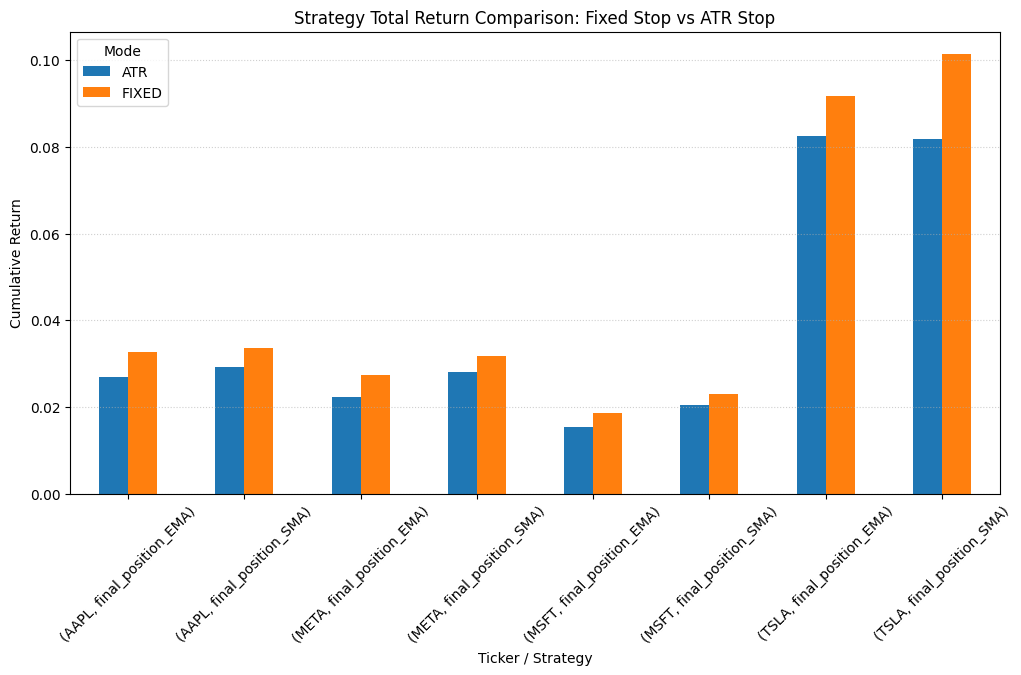

In [41]:
summary_data = []

for ticker in CONFIG["tickers"]:
    for mode in ["FIXED", "ATR"]:
        for strat in ["final_position_SMA", "final_position_EMA"]:
            df_trades = pd.read_parquet(output_dir / f"trades_{ticker}_{mode}_{strat}.parquet")

            if not df_trades.empty:
                pnl = (df_trades['Exit Price'] - df_trades['Entry Price'])
                total_return = (df_trades['Return %'] / 100 + 1).prod() - 1
                avg_duration = df_trades["Holding Days"].mean()
                win_rate = (df_trades["Return %"] > 0).sum() / len(df_trades)
            
                summary_data.append({
                    "Ticker": ticker,
                    "Mode": mode,
                    "Strategy" : strat,
                    "Total Return": total_return,
                    "Win Rate": win_rate,
                    "Avg Duration": avg_duration,
                    "PnL" : pnl
                })
            
                print(f"Last 5 trades for {ticker} ({mode.upper()}):")
                print(df_trades.tail(5))
                print(f"Total Return: {total_return:.2%}\n")
                print(f"Total PnL: ${round(pnl.sum(), 2)}\n")

# Pivot and plot the strategy returns side by side
df_summary = pd.DataFrame(summary_data)

if not df_summary.empty:
    pivot_df = df_summary.pivot(
        index=["Ticker", "Strategy"], 
        columns="Mode", 
        values="Total Return"
    )

    pivot_df.plot(kind="bar", figsize=(12, 6))
    plt.title("Strategy Total Return Comparison: Fixed Stop vs ATR Stop")
    plt.ylabel("Cumulative Return")
    plt.xlabel("Ticker / Strategy")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle=":", alpha=0.6)
    plt.show()